<a href="https://colab.research.google.com/github/poosathanusri06/CodeAlpha_internshipwork/blob/main/TASK_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. DATASET OVERVIEW & STRUCTURE
Shape of Dataset: 200 rows, 5 columns

Data Types & Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        200 non-null    int64  
 1   Age               200 non-null    int64  
 2   Annual_Income_k$  194 non-null    float64
 3   Spending_Score    200 non-null    int64  
 4   Category          200 non-null    object 
dtypes: float64(1), int64(3), object(1)
memory usage: 7.9+ KB
None

Missing Values Count:
CustomerID          0
Age                 0
Annual_Income_k$    6
Spending_Score      0
Category            0
dtype: int64

Summary Statistics (Numerical):
                  count         mean        std      min        25%      50%  \
CustomerID        200.0  1100.500000  57.879185  1001.00  1050.7500  1100.50   
Age               200.0    43.425000  14.941910    18.00    

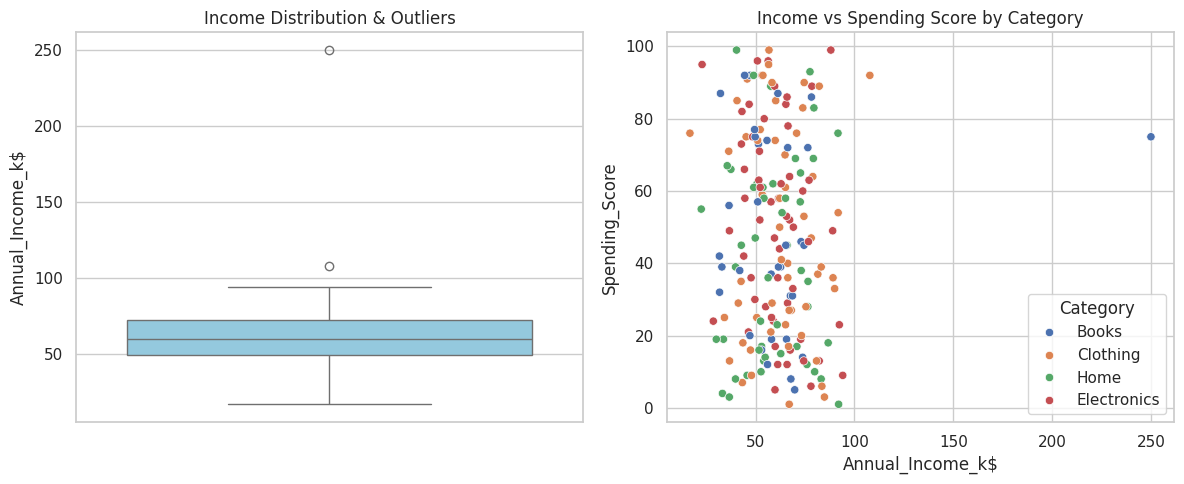


3. HYPOTHESIS TESTING
Hypothesis: Spending Score differs significantly across Categories.
ANOVA F-statistic: 1.2177, p-value: 0.3045
Result: Fail to reject H0 — No statistically significant difference detected.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style for plots
sns.set_theme(style="whitegrid")

def load_data():
    """Generates or loads a sample dataset for EDA."""
    np.random.seed(42)
    n = 200
    data = {
        'CustomerID': range(1001, 1001 + n),
        'Age': np.random.randint(18, 70, size=n),
        'Annual_Income_k$': np.random.normal(60, 15, size=n).round(2),
        'Spending_Score': np.random.randint(1, 100, size=n),
        'Category': np.random.choice(['Electronics', 'Clothing', 'Home', 'Books'], size=n)
    }

    # Introduce some artificial missing values and outliers for demonstration
    df = pd.DataFrame(data)
    df.loc[10:15, 'Annual_Income_k$'] = np.nan
    df.loc[0, 'Annual_Income_k$'] = 250.0  # Anomaly/Outlier
    return df

def explore_data_structure(df):
    """Explores basic structure and missing values."""
    print("=" * 50)
    print("1. DATASET OVERVIEW & STRUCTURE")
    print("=" * 50)
    print(f"Shape of Dataset: {df.shape[0]} rows, {df.shape[1]} columns\n")
    print("Data Types & Non-Null Counts:")
    print(df.info())
    print("\nMissing Values Count:")
    print(df.isnull().sum())
    print("\nSummary Statistics (Numerical):")
    print(df.describe().T)

def detect_anomalies_and_patterns(df):
    """Identifies trends, correlation, and anomalies."""
    print("\n" + "=" * 50)
    print("2. ANOMALY DETECTION & PATTERNS")
    print("=" * 50)

    # Outlier detection using Z-score on Income
    income_clean = df['Annual_Income_k$'].dropna()
    z_scores = np.abs(stats.zscore(income_clean))
    outliers = income_clean[z_scores > 3]
    print(f"Detected Outliers in 'Annual_Income_k$' (Z-score > 3):\n{outliers}")

    # Visualizing distribution and outliers
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.boxplot(y=df['Annual_Income_k$'], ax=axes[0], color='skyblue')
    axes[0].set_title('Income Distribution & Outliers')

    sns.scatterplot(data=df, x='Annual_Income_k$', y='Spending_Score', hue='Category', ax=axes[1])
    axes[1].set_title('Income vs Spending Score by Category')
    plt.tight_layout()
    plt.savefig('eda_patterns.png')
    plt.show()

def hypothesis_testing(df):
    """Tests hypotheses using statistical tests."""
    print("\n" + "=" * 50)
    print("3. HYPOTHESIS TESTING")
    print("=" * 50)
    # Hypothesis: Does Spending Score significantly differ by Category?
    categories = [group['Spending_Score'].values for name, group in df.groupby('Category')]
    f_val, p_val = stats.f_oneway(*categories)

    print("Hypothesis: Spending Score differs significantly across Categories.")
    print(f"ANOVA F-statistic: {f_val:.4f}, p-value: {p_val:.4f}")
    if p_val < 0.05:
        print("Result: Reject H0 — Significant difference exists between categories.")
    else:
        print("Result: Fail to reject H0 — No statistically significant difference detected.")

if __name__ == "__main__":
    df = load_data()
    explore_data_structure(df)
    detect_anomalies_and_patterns(df)
    hypothesis_testing(df)